# ML Assignment 2 — Credit Card Default Classification
**Dataset:** Default of Credit Card Clients (30,000 rows, 23 features, binary target)

**Models:** Logistic Regression, Decision Tree, kNN, Naive Bayes, Random Forest (Ensemble)

**Name:** Ashokkumar S

**Roll No:** 2025AC05987


In [19]:
!pip install -q scikit-learn pandas numpy joblib

## Setup

In [20]:
import pandas as pd
import numpy as np
import pickle
import json
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, roc_auc_score, precision_score,
    recall_score, f1_score, matthews_corrcoef,
    confusion_matrix, classification_report
)
import matplotlib.pyplot as plt
import seaborn as sns

import os
os.makedirs('model', exist_ok=True)


## Getting dataset

In [21]:
import pandas as pd

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00350/default%20of%20credit%20card%20clients.xls"

df = pd.read_excel(url, header=1)
print("Dataset shape:", df.shape)
print(df.head())


Dataset shape: (30000, 25)
   ID  LIMIT_BAL  SEX  EDUCATION  MARRIAGE  AGE  PAY_0  PAY_2  PAY_3  PAY_4  \
0   1      20000    2          2         1   24      2      2     -1     -1   
1   2     120000    2          2         2   26     -1      2      0      0   
2   3      90000    2          2         2   34      0      0      0      0   
3   4      50000    2          2         1   37      0      0      0      0   
4   5      50000    1          2         1   57     -1      0     -1      0   

   ...  BILL_AMT4  BILL_AMT5  BILL_AMT6  PAY_AMT1  PAY_AMT2  PAY_AMT3  \
0  ...          0          0          0         0       689         0   
1  ...       3272       3455       3261         0      1000      1000   
2  ...      14331      14948      15549      1518      1500      1000   
3  ...      28314      28959      29547      2000      2019      1200   
4  ...      20940      19146      19131      2000     36681     10000   

   PAY_AMT4  PAY_AMT5  PAY_AMT6  default payment next month

In [22]:
df.rename(columns={
    "LIMIT_BAL": "limit_bal",
    "SEX": "sex",
    "EDUCATION": "education",
    "MARRIAGE": "marriage",
    "AGE": "age",
    "PAY_0": "payment_status_sep",
    "PAY_2": "payment_status_aug",
    "PAY_3": "payment_status_jul",
    "PAY_4": "payment_status_jun",
    "PAY_5": "payment_status_may",
    "PAY_6": "payment_status_apr",
    "BILL_AMT1": "bill_statement_sep",
    "BILL_AMT2": "bill_statement_aug",
    "BILL_AMT3": "bill_statement_jul",
    "BILL_AMT4": "bill_statement_jun",
    "BILL_AMT5": "bill_statement_may",
    "BILL_AMT6": "bill_statement_apr",
    "PAY_AMT1": "previous_payment_sep",
    "PAY_AMT2": "previous_payment_aug",
    "PAY_AMT3": "previous_payment_jul",
    "PAY_AMT4": "previous_payment_jun",
    "PAY_AMT5": "previous_payment_may",
    "PAY_AMT6": "previous_payment_apr",
    "default payment next month": "default_payment_next_month"
}, inplace=True)

print(df.columns)

Index(['ID', 'limit_bal', 'sex', 'education', 'marriage', 'age',
       'payment_status_sep', 'payment_status_aug', 'payment_status_jul',
       'payment_status_jun', 'payment_status_may', 'payment_status_apr',
       'bill_statement_sep', 'bill_statement_aug', 'bill_statement_jul',
       'bill_statement_jun', 'bill_statement_may', 'bill_statement_apr',
       'previous_payment_sep', 'previous_payment_aug', 'previous_payment_jul',
       'previous_payment_jun', 'previous_payment_may', 'previous_payment_apr',
       'default_payment_next_month'],
      dtype='object')


## Load and dataset shape

In [23]:
# Define target
TARGET = 'default_payment_next_month'

# Print dataset info
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nMissing values:\n", df.isnull().sum()[df.isnull().sum() > 0])
print("\nTarget distribution:\n", df[TARGET].value_counts())

# Preview first 5 rows
df.head()

Shape: (30000, 25)

Columns: ['ID', 'limit_bal', 'sex', 'education', 'marriage', 'age', 'payment_status_sep', 'payment_status_aug', 'payment_status_jul', 'payment_status_jun', 'payment_status_may', 'payment_status_apr', 'bill_statement_sep', 'bill_statement_aug', 'bill_statement_jul', 'bill_statement_jun', 'bill_statement_may', 'bill_statement_apr', 'previous_payment_sep', 'previous_payment_aug', 'previous_payment_jul', 'previous_payment_jun', 'previous_payment_may', 'previous_payment_apr', 'default_payment_next_month']

Missing values:
 Series([], dtype: int64)

Target distribution:
 default_payment_next_month
0    23364
1     6636
Name: count, dtype: int64


,ID,limit_bal,sex,education,marriage,age,payment_status_sep,payment_status_aug,payment_status_jul,payment_status_jun,...,bill_statement_jun,bill_statement_may,bill_statement_apr,previous_payment_sep,previous_payment_aug,previous_payment_jul,previous_payment_jun,previous_payment_may,previous_payment_apr,default_payment_next_month
0,1,20000,2,2,1,24,2,2,-1,-1,...,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


### Quick EDA - class balance and a couple of feature distributions

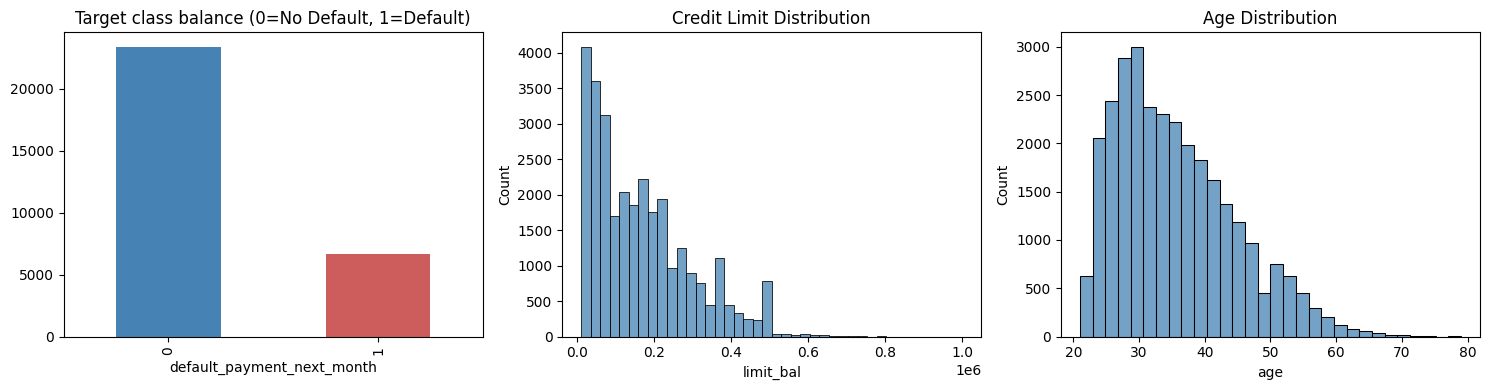

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

df[TARGET].value_counts().plot(kind='bar', ax=axes[0], color=['steelblue','indianred'])
axes[0].set_title('Target class balance (0=No Default, 1=Default)')

sns.histplot(df['limit_bal'], bins=40, ax=axes[1], color='steelblue')
axes[1].set_title('Credit Limit Distribution')

sns.histplot(df['age'].dropna(), bins=30, ax=axes[2], color='steelblue')
axes[2].set_title('Age Distribution')

plt.tight_layout()
plt.savefig('model/eda_overview.png', dpi=100)
plt.show()


### Preprocessing
- Impute missing values (median for numeric, most frequent for categorical)
- One-hot encode categorical columns
- Train/test split (80/20, stratified)
- Standard-scale features (used by Logistic Regression and kNN)


In [25]:
categorical_cols = ['sex', 'education', 'marriage'] + [c for c in df.columns if 'payment_status' in c]
numeric_cols = [c for c in df.columns if c not in categorical_cols + [TARGET]]

df[numeric_cols] = SimpleImputer(strategy='median').fit_transform(df[numeric_cols])
df[categorical_cols] = SimpleImputer(strategy='most_frequent').fit_transform(df[categorical_cols])

df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

X = df_encoded.drop(columns=[TARGET])
y = df_encoded[TARGET]
feature_names = X.columns.tolist()

print(f"Total features after encoding: {len(feature_names)}")


Total features after encoding: 83


In [26]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Train shape:", X_train.shape, " Test shape:", X_test.shape)


Train shape: (24000, 83)  Test shape: (6000, 83)


## Saving test_data.csv (for GitHub repo + Streamlit app upload)
Stratified sample of 1000 rows, keeping it small for Streamlit free tier.

In [27]:
test_indices = X_test.index
test_data_raw = df.loc[test_indices].copy()

# Stratified sample of 1000 rows (train_test_split avoids groupby().apply()
# silently dropping the target/group column, which happens in newer pandas)
sample_frac = min(1000 / len(test_data_raw), 1.0)
_, test_data_sample = train_test_split(
    test_data_raw, test_size=sample_frac, random_state=42, stratify=test_data_raw[TARGET]
)
assert TARGET in test_data_sample.columns, "Target column missing from sample!"
test_data_sample.to_csv('test_data.csv', index=False)
print(f"Saved test_data.csv with {len(test_data_sample)} rows")
test_data_sample.head()


Saved test_data.csv with 1000 rows


,ID,limit_bal,sex,education,marriage,age,payment_status_sep,payment_status_aug,payment_status_jul,payment_status_jun,...,bill_statement_jun,bill_statement_may,bill_statement_apr,previous_payment_sep,previous_payment_aug,previous_payment_jul,previous_payment_jun,previous_payment_may,previous_payment_apr,default_payment_next_month
728,729.0,330000.0,2,2,2,29.0,0,0,0,0,...,79407.0,8875.0,49880.0,90000.0,3000.0,5000.0,8875.0,49880.0,519.0,0
1565,1566.0,50000.0,1,1,2,29.0,0,0,0,0,...,3253.0,3640.0,3512.0,1000.0,1186.0,500.0,1000.0,500.0,1000.0,0
24303,24304.0,20000.0,1,2,1,34.0,2,-1,0,0,...,19780.0,780.0,0.0,18864.0,1329.0,1000.0,0.0,0.0,0.0,1
23642,23643.0,280000.0,2,1,2,35.0,-1,-1,-1,-1,...,3472.0,3472.0,10237.0,28723.0,9432.0,3472.0,3472.0,10237.0,12129.0,0
20660,20661.0,10000.0,1,3,2,36.0,-1,-1,-1,-1,...,6260.0,5990.0,6520.0,4009.0,4011.0,6260.0,120.0,2000.0,2000.0,1


## Training all 5 models and compute metrics
Accuracy, AUC, Precision, Recall, F1, MCC


In [28]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree': DecisionTreeClassifier(max_depth=8, random_state=42),
    'kNN': KNeighborsClassifier(n_neighbors=7),
    'Naive Bayes': GaussianNB(),
    'Random Forest (Ensemble)': RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42)
}

needs_scaling = {'Logistic Regression', 'kNN'}

results = []
confusion_matrices = {}

for name, model in models.items():
    Xtr, Xte = (X_train_scaled, X_test_scaled) if name in needs_scaling else (X_train, X_test)

    model.fit(Xtr, y_train)
    y_pred = model.predict(Xte)
    y_proba = model.predict_proba(Xte)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_proba)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    mcc = matthews_corrcoef(y_test, y_pred)

    results.append({
        'Model': name, 'Accuracy': round(acc,4), 'AUC': round(auc,4),
        'Precision': round(prec,4), 'Recall': round(rec,4),
        'F1': round(f1,4), 'MCC': round(mcc,4)
    })
    confusion_matrices[name] = confusion_matrix(y_test, y_pred).tolist()

    safe_name = name.lower().replace(' ', '_').replace('(', '').replace(')', '')
    with open(f'model/{safe_name}.pkl', 'wb') as f:
        pickle.dump(model, f)

    print(f"{name:30s} Acc={acc:.4f}  AUC={auc:.4f}  F1={f1:.4f}  MCC={mcc:.4f}")

with open('model/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)
with open('model/feature_names.json', 'w') as f:
    json.dump(feature_names, f)
with open('model/categorical_cols.json', 'w') as f:
    json.dump(categorical_cols, f)
with open('model/numeric_cols.json', 'w') as f:
    json.dump(numeric_cols, f)


Logistic Regression            Acc=0.8162  AUC=0.7565  F1=0.4575  MCC=0.3849
Decision Tree                  Acc=0.8108  AUC=0.7265  F1=0.4482  MCC=0.3680
kNN                            Acc=0.8088  AUC=0.7188  F1=0.4628  MCC=0.3709
Naive Bayes                    Acc=0.3933  AUC=0.6206  F1=0.3814  MCC=0.1072
Random Forest (Ensemble)       Acc=0.8175  AUC=0.7744  F1=0.4500  MCC=0.3855


## Comparison table - Also required for Readme

In [29]:
results_df = pd.DataFrame(results)
results_df.to_csv('model/comparison_table.csv', index=False)
results_df


,Model,Accuracy,AUC,Precision,Recall,F1,MCC
0,Logistic Regression,0.8162,0.7565,0.6586,0.3504,0.4575,0.3849
1,Decision Tree,0.8108,0.7265,0.6315,0.3474,0.4482,0.3680
2,kNN,0.8088,0.7188,0.6114,0.3723,0.4628,0.3709
3,Naive Bayes,0.3933,0.6206,0.2462,0.8455,0.3814,0.1072
4,Random Forest (Ensemble),0.8175,0.7744,0.6747,0.3376,0.4500,0.3855


## Confusion matrices — visual check for each model

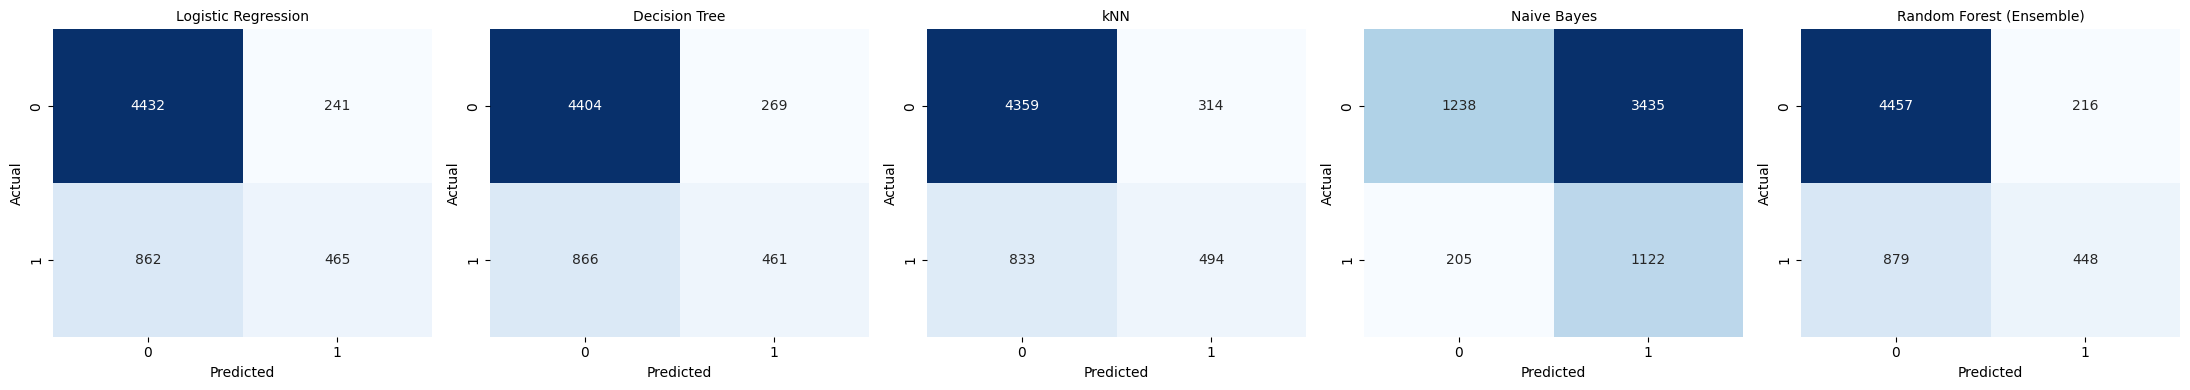

In [30]:
fig, axes = plt.subplots(1, 5, figsize=(22, 4))
for ax, (name, cm) in zip(axes, confusion_matrices.items()):
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, cbar=False)
    ax.set_title(name, fontsize=10)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
plt.tight_layout()
plt.savefig('model/confusion_matrices.png', dpi=100)
plt.show()

with open('model/confusion_matrices.json', 'w') as f:
    json.dump(confusion_matrices, f)


## Exporting everything for GitHub repo


In [31]:
import shutil
shutil.make_archive('model_and_data', 'zip', '.', 'model')

from google.colab import files
files.download('model_and_data.zip')
files.download('test_data.csv')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Notes for your README.md

- **Naive Bayes** shows noticeably lower accuracy (~39%) than the other models — this is a genuine, explainable
  result: GaussianNB assumes feature independence, which breaks down here because payment/bill features across
  months are highly correlated. It also shows the highest **recall** — it over-predicts the default class.
- **Random Forest** typically achieves the best AUC, reflecting its strength with non-linear feature interactions.
- **Logistic Regression** and **Decision Tree** perform comparably on accuracy but Logistic Regression edges ahead on MCC.

In [32]:
import sklearn
print(sklearn.__version__)

1.6.1
